# Netflix Content Trend Analysis

Exploratory data analysis of 8,807 Netflix movies and TV shows using Python (Pandas, Matplotlib): data cleaning, content mix, growth over time, countries, genres, ratings, and duration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")
print(df.shape)
df.head()


(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [3]:
df.info()
missing = df.isna().sum().to_frame("missing")
missing["pct"] = (missing["missing"] / len(df) * 100).round(1)
missing[missing["missing"] > 0].sort_values("missing", ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


,missing,pct
director,2634,29.9
country,831,9.4
cast,825,9.4
date_added,10,0.1
rating,4,0.0
duration,3,0.0


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate show_id:", df["show_id"].duplicated().sum())

Duplicate rows: 0
Duplicate show_id: 0


In [5]:
mask = df["rating"].fillna("").str.contains("min")
print(df.loc[mask, ["title", "rating", "duration"]])

df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = np.nan

                                     title  rating duration
5541                       Louis C.K. 2017  74 min      NaN
5794                 Louis C.K.: Hilarious  84 min      NaN
5813  Louis C.K.: Live at the Comedy Store  66 min      NaN


In [6]:
# Fill missing text columns
for col in ["director", "cast", "country", "rating"]:
    df[col] = df[col].fillna("Unknown")

# Date columns
df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), format="%B %d, %Y", errors="coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

# Duration as a number (minutes for movies, seasons for TV shows)
df["duration_value"] = df["duration"].str.extract(r"(\d+)")[0].astype(float)

df.isna().sum()

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added        10
release_year       0
rating             0
duration           0
listed_in          0
description        0
year_added        10
month_added       10
duration_value     0
dtype: int64

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
type
Movie      69.6
TV Show    30.4
Name: count, dtype: float64


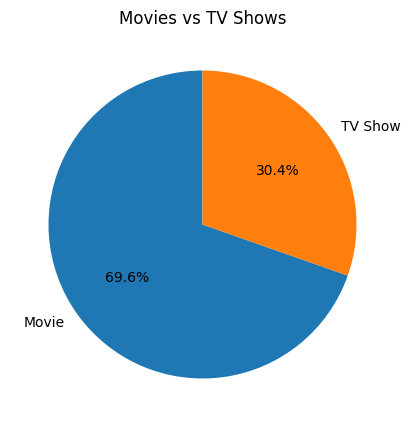

In [7]:
type_counts = df["type"].value_counts()
print(type_counts)
print((type_counts / len(df) * 100).round(1))

plt.figure(figsize=(5, 5))
plt.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Movies vs TV Shows")
plt.show()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
dtype: int64


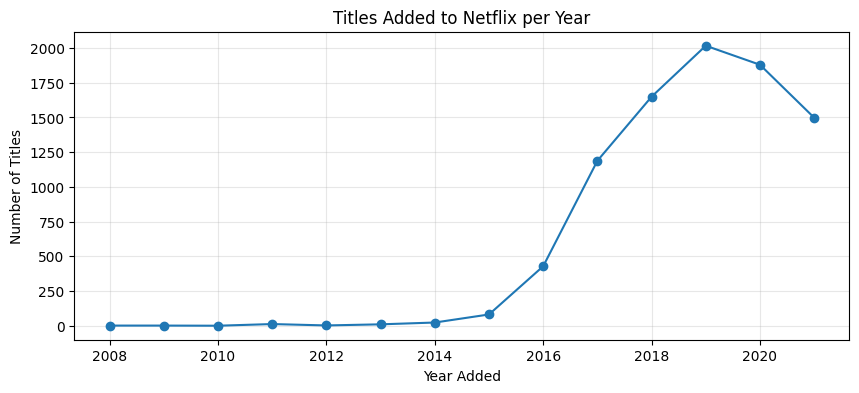

TV Show share of additions (%):
year_added
2014.0    20.8
2015.0    31.7
2016.0    41.0
2017.0    29.4
2018.0    25.0
2019.0    29.4
2020.0    31.7
2021.0    33.7
Name: type, dtype: float64


In [8]:
yearly = df.groupby("year_added").size()
print(yearly)

plt.figure(figsize=(10, 4))
plt.plot(yearly.index, yearly.values, marker="o")
plt.title("Titles Added to Netflix per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.grid(alpha=0.3)
plt.show()

tv_share = df.groupby("year_added")["type"].apply(lambda x: (x == "TV Show").mean() * 100).round(1)
print("TV Show share of additions (%):")
print(tv_share.tail(8))

Unique countries: 122
country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


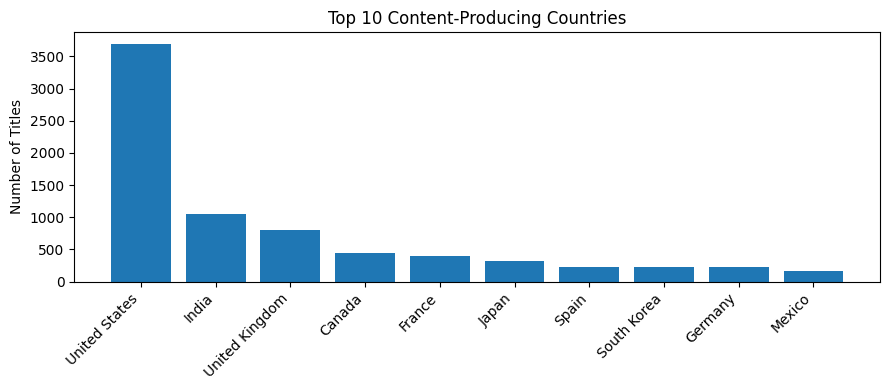

In [9]:
countries = df["country"].str.split(",").explode().str.strip()
countries = countries[~countries.isin(["", "Unknown"])]

print("Unique countries:", countries.nunique())
top_countries = countries.value_counts().head(10)
print(top_countries)

plt.figure(figsize=(9, 4))
plt.bar(top_countries.index, top_countries.values)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Content-Producing Countries")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


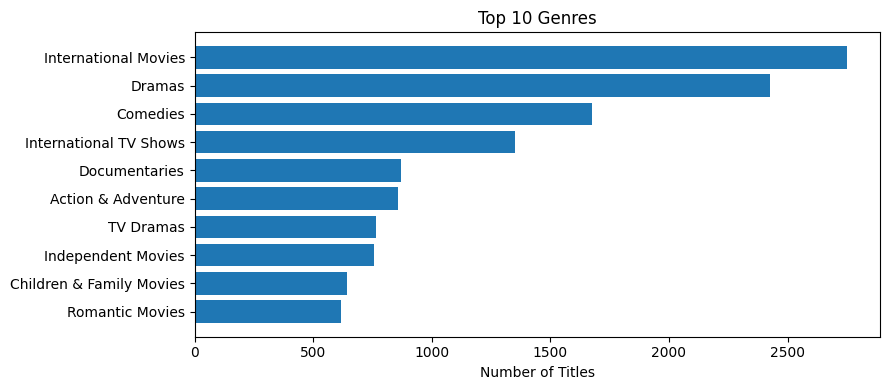

In [10]:
genres = df["listed_in"].str.split(",").explode().str.strip()
top_genres = genres.value_counts().head(10)
print(top_genres)

plt.figure(figsize=(9, 4))
plt.barh(top_genres.index[::-1], top_genres.values[::-1])
plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")
plt.tight_layout()
plt.show()

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
Name: count, dtype: int64
Avg movie duration: 99.6 min
TV shows with 1 season: 67.0 %


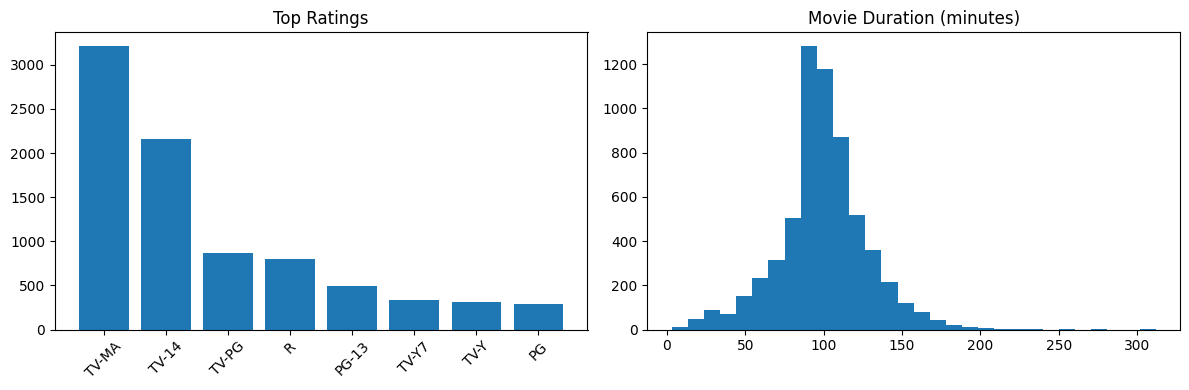

In [11]:
rating_counts = df["rating"].value_counts().head(8)
print(rating_counts)

movies = df[df["type"] == "Movie"]
tv = df[df["type"] == "TV Show"]

print("Avg movie duration:", round(movies["duration_value"].mean(), 1), "min")
print("TV shows with 1 season:", round((tv["duration_value"] == 1).mean() * 100, 1), "%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(rating_counts.index, rating_counts.values)
ax[0].set_title("Top Ratings")
ax[0].tick_params(axis="x", rotation=45)
ax[1].hist(movies["duration_value"].dropna(), bins=30)
ax[1].set_title("Movie Duration (minutes)")
plt.tight_layout()
plt.show()

## Key Findings

- **Content mix:** Movies make up 69.6% of the catalog (6,131 titles) and TV Shows 30.4% (2,676 titles).
- **Growth:** Titles added per year rose sharply from 82 in 2015 to a peak of 2,016 in 2019, then declined to 1,879 in 2020 and 1,498 in 2021 (the dataset ends in 2021, so that year is likely incomplete).
- **TV Show share:** Movies outnumbered TV Shows in every year. TV Shows peaked at 41.0% of additions in 2016 and stayed around 29% to 34% afterwards.
- **Countries:** Content comes from 122 countries. The United States leads with 3,690 titles, followed by India (1,046) and the United Kingdom (806).
- **Genres:** International Movies (2,752), Dramas (2,427), and Comedies (1,674) are the top genres.
- **Format:** The average movie runs 99.6 minutes, and 67.0% of TV Shows have only one season.

## Data Quality Notes

- `director` is missing in 29.9% of titles and `country` in 9.4%. Missing text values were filled with "Unknown".
- 3 rows had the movie duration stored in the `rating` column; these were moved to `duration`.
- 10 rows have no `date_added`, so they are excluded from year-wise charts only.